In [4]:
import tensorflow as tf
from params import PARAMS
from PreDamagePreTech import PreDamagePreTechModel

# Example usage
import numpy as np
import os
import argparse

"""
Six-regime simulator with Greek-letter variable names and an explicit
intermediate-technology state.

Regimes (whether_Tech_jump, whether_Damage_jump):
  (0,0)  PreDamage–PreTech              -> PreDamagePreTechModel
  (0,1)  PostDamage–PreTech             -> PostDamagePreTechModel
  (1,0)  PreDamage–IntermTech           -> PreDamageIntermTechModel
  (1,1)  PostDamage–IntermTech          -> PostDamageIntermTechModel
  (2,0)  PreDamage–PostTech             -> PreDamagePostTechModel
  (2,1)  PostDamage–PostTech            -> PostDamagePostTechModel

Transitions:
  • From (tech=0): a tech jump occurs with intensity J_tech = exp(logR)/varrho.
      - With prob (1−π): go to tech=1 (intermediate). Keep research active.
      - With prob π:     go to tech=2 (post). Research turns off (logR = 0).
  • From (tech=1): a further jump to tech=2 happens with intensity π * J_tech.
  • Damage jump (from damage=0 → 1) has intensity I_d(Y) and is absorbing.

Conventions:
  - Z in [0,1] is the green share (sometimes called R in older code).
  - logR is the research state; when tech=2 we pin logR := 0.
  - ξ and logξ are passed in the state as before.
  - λ₃ stores the realized damage jump magnitude after the damage jump; 0 otherwise.
  - A_g_level stores the realized tech level parameter after a tech jump; drawn
    from A_g_prime_list for tech=1 and A_g_prime_prime_list for tech=2 (fallbacks
    to scalar PARAMS if lists are not provided).
"""

#############################################
# CLI args
#############################################
# parser = argparse.ArgumentParser(description="seed sets")
# parser.add_argument("--id", type=int, default=1)
# parser.add_argument("--xi", type=float, required=True)
# args = parser.parse_args()

# seed = args.id
# ξ = tf.constant(args.xi, dtype=tf.float32)
# logξ = tf.math.log(ξ)
seed  = 1
ξ = tf.constant(0.1, dtype=tf.float32)
logξ = tf.math.log(ξ)

# Output folders
output_folder = f"/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/SimulationResults/paths_ξ_{ξ}/"
os.makedirs(output_folder, exist_ok=True)

export_folder =  "/project/lhansen/Cap_damage/TwoStageTechJump_SITE_Pretrain/output_shorterRun/TechSearch_LR_warmup_cosine_10e-6,10e-6,10e-6,10e-6_128_neurons_32_#HiddenLayer_4_num_iterations1000000"
 

# Hyperparams required by model constructors/build
batch_size = 128
num_iterations = 2_000_000
pretrained_path = None
logging_frequency = 1000
learning_rates = [float(x) for x in "10e-4,10e-4,10e-4,10e-4".split(",")]
hidden_layer_activations = [x if x != "None" else None for x in "swish,tanh,tanh,softplus".split(",")]
output_layer_activations = [x if x != "None" else None for x in "softplus,custom,custom,softplus".split(",")]
num_hidden_layers = 4
num_neurons = 32
learning_rate_schedule_type = "piecewiseconstant"

v_nn_config   = {"num_hiddens":[num_neurons]*num_hidden_layers, "use_bias":True, "activation":hidden_layer_activations[0], "dim":1, "nn_name":"v_nn"}
v_nn_config["final_activation"] = output_layer_activations[0]

i_g_nn_config = {"num_hiddens":[num_neurons]*num_hidden_layers, "use_bias":True, "activation":hidden_layer_activations[1], "dim":1, "nn_name":"i_g_nn"}
i_g_nn_config["final_activation"] = output_layer_activations[1]

i_d_nn_config = {"num_hiddens":[num_neurons]*num_hidden_layers, "use_bias":True, "activation":hidden_layer_activations[2], "dim":1, "nn_name":"i_d_nn"}
i_d_nn_config["final_activation"] = output_layer_activations[2]

i_r_nn_config = {"num_hiddens":[num_neurons]*num_hidden_layers, "use_bias":True, "activation":hidden_layer_activations[3], "dim":1, "nn_name":"i_r_nn"}
i_r_nn_config["final_activation"] = output_layer_activations[3]

params = {
    "batch_size": batch_size,
    "learning_rates": learning_rates,
    "v_nn_config": v_nn_config,
    "i_g_nn_config": i_g_nn_config,
    "i_d_nn_config": i_d_nn_config,
    "i_r_nn_config": i_r_nn_config,
    "num_iterations": num_iterations,
    "logging_frequency": logging_frequency,
    "verbose": True,
    "pretrained_path": pretrained_path,
    "learning_rate_schedule_type": learning_rate_schedule_type,
}

# Custom output activations with φ_g, φ_d (keep Greek)
φ_g = 16.7
φ_d = 16.7
if output_layer_activations[1] == "custom" or output_layer_activations[2] == "custom":
    params["i_g_nn_config"]["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ φ_g) / (tf.exp(2 * x) + 1.0)
    params["i_d_nn_config"]["final_activation"] = lambda x: 1.0 - (1.0 + 1.0/ φ_d) / (tf.exp(2 * x) + 1.0)

PARAMS.update(params)

PARAMS.update({
    # PreDamage–PreTech (has i_r)
    "v_PreDamagePreTech_nn_path":   v_nn_checkpoint_PreDamagePreTech_path,
    "i_g_PreDamagePreTech_nn_path": i_g_nn_checkpoint_PreDamagePreTech_path,
    "i_d_PreDamagePreTech_nn_path": i_d_nn_checkpoint_PreDamagePreTech_path,
    "i_r_PreDamagePreTech_nn_path": i_r_nn_checkpoint_PreDamagePreTech_path,

    # PostDamage–PreTech (has i_r)
    "v_PostDamagePreTech_nn_path":   v_nn_checkpoint_PostDamagePreTech_path,
    "i_g_PostDamagePreTech_nn_path": i_g_nn_checkpoint_PostDamagePreTech_path,
    "i_d_PostDamagePreTech_nn_path": i_d_nn_checkpoint_PostDamagePreTech_path,
    "i_r_PostDamagePreTech_nn_path": i_r_nn_checkpoint_PostDamagePreTech_path,

    # PreDamage–IntermTech (has i_r)
    "v_PreDamageIntermTech_nn_path":   v_nn_checkpoint_PreDamageIntermTech_path,
    "i_g_PreDamageIntermTech_nn_path": i_g_nn_checkpoint_PreDamageIntermTech_path,
    "i_d_PreDamageIntermTech_nn_path": i_d_nn_checkpoint_PreDamageIntermTech_path,
    "i_r_PreDamageIntermTech_nn_path": i_r_nn_checkpoint_PreDamageIntermTech_path,

    # PostDamage–IntermTech (has i_r)
    "v_PostDamageIntermTech_nn_path":   v_nn_checkpoint_PostDamageIntermTech_path,
    "i_g_PostDamageIntermTech_nn_path": i_g_nn_checkpoint_PostDamageIntermTech_path,
    "i_d_PostDamageIntermTech_nn_path": i_d_nn_checkpoint_PostDamageIntermTech_path,
    "i_r_PostDamageIntermTech_nn_path": i_r_nn_checkpoint_PostDamageIntermTech_path,

    # PreDamage–PostTech (no i_r; post-tech fixes logR=0)
    "v_PreDamagePostTech_nn_path":   v_nn_checkpoint_PreDamagePostTech_path,
    "i_g_PreDamagePostTech_nn_path": i_g_nn_checkpoint_PreDamagePostTech_path,
    "i_d_PreDamagePostTech_nn_path": i_d_nn_checkpoint_PreDamagePostTech_path,

    # PostDamage–PostTech (no i_r)
    "v_PostDamagePostTech_nn_path":   v_nn_checkpoint_PostDamagePostTech_path,
    "i_g_PostDamagePostTech_nn_path": i_g_nn_checkpoint_PostDamagePostTech_path,
    "i_d_PostDamagePostTech_nn_path": i_d_nn_checkpoint_PostDamagePostTech_path,
})

#############################################
# Checkpoint paths (unchanged from your original layout)
#############################################

v_nn_checkpoint_PostDamagePostTech_path   = export_folder+"/PostDamagePostTech"+"/v_nn_checkpoint_PostDamagePostTech"
i_g_nn_checkpoint_PostDamagePostTech_path = export_folder+"/PostDamagePostTech"+"/i_g_nn_checkpoint_PostDamagePostTech"
i_d_nn_checkpoint_PostDamagePostTech_path = export_folder+"/PostDamagePostTech"+"/i_d_nn_checkpoint_PostDamagePostTech"

v_nn_checkpoint_PostDamageIntermTech_path   = export_folder+"/PostDamageIntermTech"+"/v_nn_checkpoint_PostDamageIntermTech"
i_g_nn_checkpoint_PostDamageIntermTech_path = export_folder+"/PostDamageIntermTech"+"/i_g_nn_checkpoint_PostDamageIntermTech"
i_d_nn_checkpoint_PostDamageIntermTech_path = export_folder+"/PostDamageIntermTech"+"/i_d_nn_checkpoint_PostDamageIntermTech"
i_r_nn_checkpoint_PostDamageIntermTech_path = export_folder+"/PostDamageIntermTech"+"/i_r_nn_checkpoint_PostDamageIntermTech"

v_nn_checkpoint_PostDamagePreTech_path   = export_folder+"/PostDamagePreTech"+"/v_nn_checkpoint_PostDamagePreTech"
i_g_nn_checkpoint_PostDamagePreTech_path = export_folder+"/PostDamagePreTech"+"/i_g_nn_checkpoint_PostDamagePreTech"
i_d_nn_checkpoint_PostDamagePreTech_path = export_folder+"/PostDamagePreTech"+"/i_d_nn_checkpoint_PostDamagePreTech"
i_r_nn_checkpoint_PostDamagePreTech_path = export_folder+"/PostDamagePreTech"+"/i_r_nn_checkpoint_PostDamagePreTech"

v_nn_checkpoint_PreDamageIntermTech_path   = export_folder+"/PreDamageIntermTech"+"/v_nn_checkpoint_PreDamageIntermTech"
i_g_nn_checkpoint_PreDamageIntermTech_path = export_folder+"/PreDamageIntermTech"+"/i_g_nn_checkpoint_PreDamageIntermTech"
i_d_nn_checkpoint_PreDamageIntermTech_path = export_folder+"/PreDamageIntermTech"+"/i_d_nn_checkpoint_PreDamageIntermTech"
i_r_nn_checkpoint_PreDamageIntermTech_path = export_folder+"/PreDamageIntermTech"+"/i_r_nn_checkpoint_PreDamageIntermTech"

v_nn_checkpoint_PreDamagePostTech_path   = export_folder+"/PreDamagePostTech"+"/v_nn_checkpoint_PreDamagePostTech"
i_g_nn_checkpoint_PreDamagePostTech_path = export_folder+"/PreDamagePostTech"+"/i_g_nn_checkpoint_PreDamagePostTech"
i_d_nn_checkpoint_PreDamagePostTech_path = export_folder+"/PreDamagePostTech"+"/i_d_nn_checkpoint_PreDamagePostTech"

v_nn_checkpoint_PreDamagePreTech_path   = export_folder+"/PreDamagePreTech"+"/v_nn_checkpoint_PreDamagePreTech"
i_g_nn_checkpoint_PreDamagePreTech_path = export_folder+"/PreDamagePreTech"+"/i_g_nn_checkpoint_PreDamagePreTech"
i_d_nn_checkpoint_PreDamagePreTech_path = export_folder+"/PreDamagePreTech"+"/i_d_nn_checkpoint_PreDamagePreTech"
i_r_nn_checkpoint_PreDamagePreTech_path = export_folder+"/PreDamagePreTech"+"/i_r_nn_checkpoint_PreDamagePreTech"


def load_model(model, n_inputs, v_path, ig_path, id_path, ir_path=None):
    m = model(PARAMS)
    m.v_nn.build((params["batch_size"], n_inputs))
    m.i_g_nn.build((params["batch_size"], n_inputs))
    m.i_d_nn.build((params["batch_size"], n_inputs))
    m.v_nn.load_weights(v_path)
    m.i_g_nn.load_weights(ig_path)
    m.i_d_nn.load_weights(id_path)
    if ir_path is not None:
        m.i_r_nn.build((params["batch_size"], n_inputs))
        m.i_r_nn.load_weights(ir_path)
    return m

# Load regime models (best-effort)
try:
    from PostDamagePostTech import PostDamagePostTechModel
    PostDamagePostTech_model = load_model(PostDamagePostTechModel, 7,
        v_nn_checkpoint_PostDamagePostTech_path,
        i_g_nn_checkpoint_PostDamagePostTech_path,
        i_d_nn_checkpoint_PostDamagePostTech_path)
except Exception as e:
    print("Warn: PostDamagePostTechModel:", e)
    PostDamagePostTech_model = None

try:
    from PostDamageIntermTech import PostDamageIntermTechModel
    PostDamageIntermTech_model = load_model(PostDamageIntermTechModel, 8,
        v_nn_checkpoint_PostDamageIntermTech_path,
        i_g_nn_checkpoint_PostDamageIntermTech_path,
        i_d_nn_checkpoint_PostDamageIntermTech_path,
        i_r_nn_checkpoint_PostDamageIntermTech_path)
except Exception as e:
    print("Warn: PostDamageIntermTechModel:", e)
    PostDamageIntermTech_model = None

try:
    from PostDamagePreTech import PostDamagePreTechModel
    PostDamagePreTech_model = load_model(PostDamagePreTechModel, 8,
        v_nn_checkpoint_PostDamagePreTech_path,
        i_g_nn_checkpoint_PostDamagePreTech_path,
        i_d_nn_checkpoint_PostDamagePreTech_path,
        i_r_nn_checkpoint_PostDamagePreTech_path)
except Exception as e:
    print("Warn: PostDamagePreTechModel:", e)
    PostDamagePreTech_model = None

try:
    from PreDamageIntermTech import PreDamageIntermTechModel
    PreDamageIntermTech_model = load_model(PreDamageIntermTechModel, 7,
        v_nn_checkpoint_PreDamageIntermTech_path,
        i_g_nn_checkpoint_PreDamageIntermTech_path,
        i_d_nn_checkpoint_PreDamageIntermTech_path,
        i_r_nn_checkpoint_PreDamageIntermTech_path)
except Exception as e:
    print("Warn: PreDamageIntermTechModel:", e)
    PreDamageIntermTech_model = None

try:
    from PreDamagePostTech import PreDamagePostTechModel
    PreDamagePostTech_model = load_model(PreDamagePostTechModel, 6,
        v_nn_checkpoint_PreDamagePostTech_path,
        i_g_nn_checkpoint_PreDamagePostTech_path,
        i_d_nn_checkpoint_PreDamagePostTech_path)
except Exception as e:
    print("Warn: PreDamagePostTechModel:", e)
    PreDamagePostTech_model = None

try:
    # PreDamagePreTechModel already imported
    PreDamagePreTech_model = load_model(PreDamagePreTechModel, 7,
        v_nn_checkpoint_PreDamagePreTech_path,
        i_g_nn_checkpoint_PreDamagePreTech_path,
        i_d_nn_checkpoint_PreDamagePreTech_path,
        i_r_nn_checkpoint_PreDamagePreTech_path)
except Exception as e:
    print("Warn: PreDamagePreTechModel:", e)
    PreDamagePreTech_model = None

#############################################
# Pull parameters, keeping Greek symbols
#############################################
A_d = PARAMS['A_d']; A_g = PARAMS['A_g']
A_g_prime = PARAMS['A_g_prime']
A_g_prime_prime = PARAMS['A_g_prime_prime']
α_d = PARAMS['α_d']; Γ_d = PARAMS['Γ_d']; θ_d = PARAMS['θ_d']; σ_d = PARAMS['σ_d']
α_g = PARAMS['α_g']; Γ_g = PARAMS['Γ_g']; θ_g = PARAMS['θ_g']; σ_g = PARAMS['σ_g']
ζ = PARAMS['ζ']; ψ0 = PARAMS['ψ0']; ψ1 = PARAMS['ψ1']; σ_κ = PARAMS['σ_κ']
θ_bar = PARAMS['θ_bar']; η = PARAMS['η'];  ϛ = PARAMS['ϛ']
varrho = PARAMS['varrho']
π = PARAMS['π']
λ1 = PARAMS['λ1']; λ2 = PARAMS['λ2']; L = PARAMS['L']
λ3_values = PARAMS['λ3_values']
r1 = PARAMS['r1']; r2 = PARAMS['r2']
y_lower = PARAMS['y_lower']; y_upper = PARAMS['y_upper']

# Time step
dt = tf.constant(1/12, dtype=tf.float32)  # monthly
scale = tf.sqrt(dt)

#############################################
# Iterator for one time step across six regimes
#############################################

def _draw(list_or_scalar):
    if isinstance(list_or_scalar, (list, tuple)):
        tensor = tf.convert_to_tensor(list_or_scalar, dtype=tf.float32)
    else:
        tensor = tf.convert_to_tensor([list_or_scalar], dtype=tf.float32)
    n = tf.shape(tensor)[0]
    idx = tf.random.uniform((), minval=0, maxval=n, dtype=tf.int32)
    return tensor[idx]


 

In [6]:

def iterate_state(logK, Z, Y, logR, A_g_level, λ3, whether_Tech_jump, whether_Damage_jump):
    # Wiener increments
    dW = tf.random.normal([4]) * scale
    dW_g, dW_d, dW_Y, dW_logR = tf.unstack(dW)

    # Diffusions
    σK_d = σ_d * (1 - Z)
    σK_g = σ_g * Z
    σZ_d = - σ_d * Z * (1 - Z)
    σZ_g =   σ_g * Z * (1 - Z)
    σlogR = σ_κ
    σY = θ_bar * η * A_d * (1 - Z) * tf.exp(logK)

    K = tf.exp(logK)

    # -------------- (0,0): PreDamage–PreTech --------------
    if (whether_Tech_jump == 0) and (whether_Damage_jump == 0):
        model = PreDamagePreTech_model
        state = tf.reshape(tf.stack([logK, Z, Y, logR, logξ, logξ, logξ], axis=0), (1,7))
        # X = tf.concat([logK, Z, Y, logR,   logξ, logξ, logξ], 1)
        # i_g = model.i_g_nn(state)
        # i_d = model.i_d_nn(state)
        # i_r = tf.exp(-model.i_r_nn(state))
        
        i_g = tf.squeeze(model.i_g_nn(state))          # shape []
        i_d = tf.squeeze(model.i_d_nn(state))          # shape []
        i_r = tf.exp(-tf.squeeze(model.i_r_nn(state))) # shape []
        

        vkk = (σ_d**2 * (1 - Z)**2 + σ_g**2 * Z**2)/2.0
        # inside_d = tf.reshape(tf.maximum(1.0 + θ_d * i_d, 1e-8), [1,1])
        # inside_g = tf.reshape(tf.maximum(1.0 + θ_g * i_g, 1e-8), [1,1])
                
        inside_d =  tf.maximum(1.0 + θ_d * i_d, 1e-8) 
        inside_g =  tf.maximum(1.0 + θ_g * i_g, 1e-8) 
        

        v_logK = (α_d + Γ_d * tf.math.log(inside_d)) * (1 - Z) + (α_g + Γ_g * tf.math.log(inside_g)) * Z - vkk
        v_Z    = (α_g + Γ_g * tf.math.log(inside_g) - (α_d + Γ_d * tf.math.log(inside_d)) - Z*σ_g**2 + (1-Z)*σ_d**2) * Z * (1 - Z)
        v_Y    = θ_bar * η * A_d * (1 - Z) * K
        v_logR = - ζ + ψ0 * tf.exp(ψ1 * (tf.math.log(i_r) + logK - logR)) + 0.5 * σ_κ**2

        new_logK = logK + v_logK * dt + σK_d * dW_d + σK_g * dW_g
        new_Z    = Z    + v_Z    * dt + σZ_d * dW_d + σZ_g * dW_g
        new_logR = logR + v_logR * dt + σlogR * dW_logR
        new_Y    = Y    + v_Y    * dt + σY * dW_Y

        # Damage jump
        I_d = r1 * (tf.exp(r2/2.0 * tf.pow(new_Y - y_lower, 2)) - 1.0) * tf.cast(new_Y > y_lower, tf.float32)
        p_dmg = 1.0 - tf.exp(-I_d * dt)
        dmg_occurs = tf.random.uniform(()) < p_dmg
        new_wD = whether_Damage_jump + tf.cast(dmg_occurs, tf.int32)
        λ3_draw = _draw(PARAMS.get("λ3_values", np.linspace(PARAMS["λ3_min"], PARAMS["λ3_max"], PARAMS["L"]).tolist()))
        new_λ3 = tf.where(dmg_occurs, λ3_draw, λ3)
        new_Y  = tf.where(dmg_occurs, tf.constant(PARAMS["y_upper"], tf.float32), new_Y)

        # Tech jump from 0 → {1,2}
        J_tech = tf.exp(new_logR) / varrho
        p_tech = 1.0 - tf.exp(-J_tech * dt)
        tech_event = tf.random.uniform(()) < p_tech
        # split: (1-π) to intermediate, π to post
        u = tf.random.uniform(())
        next_T = tf.where(u < (1.0 - π), tf.constant(1, tf.int32), tf.constant(2, tf.int32))
        new_wT = tf.where(tech_event, next_T, whether_Tech_jump)
        # draw A_g level depending on where we land
        A1 = A_g_prime
        A2 = A_g_prime_prime
        new_A = tf.where(tech_event, tf.where(next_T==1, A1, A2), A_g_level)
        # if we go to post (2), research turns off
        new_logR = tf.where(tech_event & (next_T==2), tf.constant(0.0, tf.float32), new_logR)

        return new_logK, new_Z, new_logR, new_Y, new_A, new_λ3, new_wT, new_wD

    # -------------- (0,1): PostDamage–PreTech --------------
    elif (whether_Tech_jump == 0) and (whether_Damage_jump == 1):
        model = PostDamagePreTech_model
        if model is None:
            raise RuntimeError("PostDamagePreTech_model not loaded")
        state = tf.reshape(tf.stack([logK, Z, Y, logR, λ3, logξ, logξ, logξ], axis=0), (1,8))
        # X = tf.concat([logK, Z, Y, logR, λ3, logξ, logξ, logξ], 1)
 
        # i_g = model.i_g_nn(state)
        # i_d = model.i_d_nn(state)
        # i_r = tf.exp(-model.i_r_nn(state))
        
        i_g = tf.squeeze(model.i_g_nn(state))          # shape []
        i_d = tf.squeeze(model.i_d_nn(state))          # shape []
        i_r = tf.exp(-tf.squeeze(model.i_r_nn(state))) # shape []
        

        vkk = (σ_d**2 * (1 - Z)**2 + σ_g**2 * Z**2)/2.0
        # inside_d = tf.reshape(tf.maximum(1.0 + θ_d * i_d, 1e-8), [1,1])
        # inside_g = tf.reshape(tf.maximum(1.0 + θ_g * i_g, 1e-8), [1,1])
                
        inside_d =  tf.maximum(1.0 + θ_d * i_d, 1e-8) 
        inside_g =  tf.maximum(1.0 + θ_g * i_g, 1e-8) 
         

        vkk = (σ_d**2 * (1 - Z)**2 + σ_g**2 * Z**2)/2.0 

        v_logK = (α_d + Γ_d * tf.math.log(inside_d)) * (1 - Z) + (α_g + Γ_g * tf.math.log(inside_g)) * Z - vkk
        v_Z    = (α_g + Γ_g * tf.math.log(inside_g) - (α_d + Γ_d * tf.math.log(inside_d)) - Z*σ_g**2 + (1-Z)*σ_d**2) * Z * (1 - Z)
        v_Y    = θ_bar * η * A_d * (1 - Z) * K
        v_logR = - ζ + ψ0 * tf.exp(ψ1 * (tf.math.log(i_r) + logK - logR)) + 0.5 * σ_κ**2

        new_logK = logK + v_logK * dt + σK_d * dW_d + σK_g * dW_g
        new_Z    = Z    + v_Z    * dt + σZ_d * dW_d + σZ_g * dW_g
        new_logR = logR + v_logR * dt + σlogR * dW_logR
        new_Y    = Y    + v_Y    * dt + σY * dW_Y

        # Tech jump 0 → {1,2}
        J_tech = tf.exp(new_logR) / varrho
        p_tech = 1.0 - tf.exp(-J_tech * dt)
        tech_event = tf.random.uniform(()) < p_tech
        u = tf.random.uniform(())
        next_T = tf.where(u < (1.0 - π), tf.constant(1, tf.int32), tf.constant(2, tf.int32))
        new_wT = tf.where(tech_event, next_T, whether_Tech_jump) 
        new_A = tf.where(tech_event, tf.where(next_T==1, A_g_prime, A_g_prime_prime), A_g_level)
        new_logR = tf.where(tech_event & (next_T==2), tf.constant(0.0, tf.float32), new_logR)

        return new_logK, new_Z, new_logR, new_Y, new_A, λ3, new_wT, whether_Damage_jump

    # -------------- (1,0): PreDamage–IntermTech --------------
    elif (whether_Tech_jump == 1) and (whether_Damage_jump == 0):
        model = PreDamageIntermTech_model
        if model is None:
            raise RuntimeError("PreDamageIntermTech_model not loaded")
        state = tf.reshape(tf.stack([logK, Z, Y, logR, logξ, logξ, logξ], axis=0), (1,7))
        # X = tf.concat([logK, Z, Y, logR,   logξ, logξ, logξ], 1)
 
        # i_g = model.i_g_nn(state)
        # i_d = model.i_d_nn(state)
        # i_r = tf.exp(-model.i_r_nn(state))
        
        i_g = tf.squeeze(model.i_g_nn(state))          # shape []
        i_d = tf.squeeze(model.i_d_nn(state))          # shape []
        i_r = tf.exp(-tf.squeeze(model.i_r_nn(state))) # shape []
        

        vkk = (σ_d**2 * (1 - Z)**2 + σ_g**2 * Z**2)/2.0
        # inside_d = tf.reshape(tf.maximum(1.0 + θ_d * i_d, 1e-8), [1,1])
        # inside_g = tf.reshape(tf.maximum(1.0 + θ_g * i_g, 1e-8), [1,1])
                
        inside_d =  tf.maximum(1.0 + θ_d * i_d, 1e-8) 
        inside_g =  tf.maximum(1.0 + θ_g * i_g, 1e-8) 
        
 
        v_logK = (α_d + Γ_d * tf.math.log(inside_d)) * (1 - Z) + (α_g + Γ_g * tf.math.log(inside_g)) * Z - vkk
        v_Z    = (α_g + Γ_g * tf.math.log(inside_g) - (α_d + Γ_d * tf.math.log(inside_d)) - Z*σ_g**2 + (1-Z)*σ_d**2) * Z * (1 - Z)
        v_Y    = θ_bar * η * A_d * (1 - Z) * K
        v_logR = - ζ + ψ0 * tf.exp(ψ1 * (tf.math.log(i_r) + logK - logR)) + 0.5 * σ_κ**2

        new_logK = logK + v_logK * dt + σK_d * dW_d + σK_g * dW_g
        new_Z    = Z    + v_Z    * dt + σZ_d * dW_d + σZ_g * dW_g
        new_logR = logR + v_logR * dt + σlogR * dW_logR
        new_Y    = Y    + v_Y    * dt + σY * dW_Y

        # Damage jump (still possible)
        I_d = r1 * (tf.exp(r2/2.0 * tf.pow(new_Y - y_lower, 2)) - 1.0) * tf.cast(new_Y > y_lower, tf.float32)
        p_dmg = 1.0 - tf.exp(-I_d * dt)
        dmg_occurs = tf.random.uniform(()) < p_dmg
        new_wD = whether_Damage_jump + tf.cast(dmg_occurs, tf.int32)
        λ3_draw = _draw(PARAMS.get("λ3_values", np.linspace(PARAMS["λ3_min"], PARAMS["λ3_max"], PARAMS["L"]).tolist()))
        new_λ3 = tf.where(dmg_occurs, λ3_draw, λ3)
        new_Y  = tf.where(dmg_occurs, tf.constant(PARAMS["y_upper"], tf.float32), new_Y)

        # Interm → Post with intensity π * J_tech
        J_tech = tf.exp(new_logR) / varrho
        p_post = 1.0 - tf.exp(-π * J_tech * dt)
        to_post = tf.random.uniform(()) < p_post
        new_wT = tf.where(to_post, tf.constant(2, tf.int32), tf.constant(1, tf.int32))
        A2 = _draw(PARAMS.get("A_g_prime_prime_list", [A_g_prime_prime]))
        new_A = tf.where(to_post, A2, A_g_level)
        new_logR = tf.where(to_post, tf.constant(0.0, tf.float32), new_logR)

        return new_logK, new_Z, new_logR, new_Y, new_A, new_λ3, new_wT, new_wD

    # -------------- (1,1): PostDamage–IntermTech --------------
    elif (whether_Tech_jump == 1) and (whether_Damage_jump == 1):
        model = PostDamageIntermTech_model
        if model is None:
            raise RuntimeError("PostDamageIntermTech_model not loaded")
        state = tf.reshape(tf.stack([logK, Z, Y, logR, λ3, logξ, logξ, logξ], axis=0), (1,8))
        # X = tf.concat([logK, Z, Y, logR, λ3, logξ, logξ, logξ], 1)
        # i_g = model.i_g_nn(state)
        # i_d = model.i_d_nn(state)
        # i_r = tf.exp(-model.i_r_nn(state))
        
        i_g = tf.squeeze(model.i_g_nn(state))          # shape []
        i_d = tf.squeeze(model.i_d_nn(state))          # shape []
        i_r = tf.exp(-tf.squeeze(model.i_r_nn(state))) # shape []
        

        vkk = (σ_d**2 * (1 - Z)**2 + σ_g**2 * Z**2)/2.0
        # inside_d = tf.reshape(tf.maximum(1.0 + θ_d * i_d, 1e-8), [1,1])
        # inside_g = tf.reshape(tf.maximum(1.0 + θ_g * i_g, 1e-8), [1,1])
                
        inside_d =  tf.maximum(1.0 + θ_d * i_d, 1e-8) 
        inside_g =  tf.maximum(1.0 + θ_g * i_g, 1e-8) 
        

        v_logK = (α_d + Γ_d * tf.math.log(inside_d)) * (1 - Z) + (α_g + Γ_g * tf.math.log(inside_g)) * Z - vkk
        v_Z    = (α_g + Γ_g * tf.math.log(inside_g) - (α_d + Γ_d * tf.math.log(inside_d)) - Z*σ_g**2 + (1-Z)*σ_d**2) * Z * (1 - Z)
        v_Y    = θ_bar * η * A_d * (1 - Z) * K
        v_logR = - ζ + ψ0 * tf.exp(ψ1 * (tf.math.log(i_r) + logK - logR)) + 0.5 * σ_κ**2

        new_logK = logK + v_logK * dt + σK_d * dW_d + σK_g * dW_g
        new_Z    = Z    + v_Z    * dt + σZ_d * dW_d + σZ_g * dW_g
        new_logR = logR + v_logR * dt + σlogR * dW_logR
        new_Y    = Y    + v_Y    * dt + σY * dW_Y

        # Interm → Post with intensity π * J_tech
        J_tech = tf.exp(new_logR) / varrho
        p_post = 1.0 - tf.exp(-π * J_tech * dt)
        to_post = tf.random.uniform(()) < p_post
        new_wT = tf.where(to_post, tf.constant(2, tf.int32), tf.constant(1, tf.int32))
        A2 =  A_g_prime_prime 
        new_A = tf.where(to_post, A2, A_g_level)
        new_logR = tf.where(to_post, tf.constant(0.0, tf.float32), new_logR)

        return new_logK, new_Z, new_logR, new_Y, new_A, λ3, new_wT, whether_Damage_jump

    # -------------- (2,0): PreDamage–PostTech --------------
    elif (whether_Tech_jump == 2) and (whether_Damage_jump == 0):
        model = PreDamagePostTech_model
        if model is None:
            raise RuntimeError("PreDamagePostTech_model not loaded")
        state = tf.reshape(tf.stack([logK, Z, Y, A_g_level, logξ, logξ], axis=0), (1,6))
        # X = tf.concat([logK, Z, Y, A_g_prime_prime *  tf.ones(tf.shape(Y)), logξ, logξ], 1)
        # i_g = model.i_g_nn(state)
        # i_d = model.i_d_nn(state) 
        
        i_g = tf.squeeze(model.i_g_nn(state))          # shape []
        i_d = tf.squeeze(model.i_d_nn(state))          # shape []
 
        

        vkk = (σ_d**2 * (1 - Z)**2 + σ_g**2 * Z**2)/2.0
        # inside_d = tf.reshape(tf.maximum(1.0 + θ_d * i_d, 1e-8), [1,1])
        # inside_g = tf.reshape(tf.maximum(1.0 + θ_g * i_g, 1e-8), [1,1])
                
        inside_d =  tf.maximum(1.0 + θ_d * i_d, 1e-8) 
        inside_g =  tf.maximum(1.0 + θ_g * i_g, 1e-8) 
        

        v_logK = (α_d + Γ_d * tf.math.log(inside_d)) * (1 - Z) + (α_g + Γ_g * tf.math.log(inside_g)) * Z - vkk
        v_Z    = (α_g + Γ_g * tf.math.log(inside_g) - (α_d + Γ_d * tf.math.log(inside_d)) - Z*σ_g**2 + (1-Z)*σ_d**2) * Z * (1 - Z)
        v_Y    = θ_bar * η * A_d * (1 - Z) * K

        new_logK = logK + v_logK * dt + σK_d * dW_d + σK_g * dW_g
        new_Z    = Z    + v_Z    * dt + σZ_d * dW_d + σZ_g * dW_g
        new_logR = tf.constant(0.0, tf.float32)
        new_Y    = Y    + v_Y    * dt + σY * dW_Y

        # Damage jump
        I_d = r1 * (tf.exp(r2/2.0 * tf.pow(new_Y - y_lower, 2)) - 1.0) * tf.cast(new_Y > y_lower, tf.float32)
        p_dmg = 1.0 - tf.exp(-I_d * dt)
        dmg_occurs = tf.random.uniform(()) < p_dmg
        new_wD = whether_Damage_jump + tf.cast(dmg_occurs, tf.int32)
        λ3_draw = _draw(PARAMS.get("λ3_values", np.linspace(PARAMS["λ3_min"], PARAMS["λ3_max"], PARAMS["L"]).tolist()))
        new_λ3 = tf.where(dmg_occurs, λ3_draw, λ3)
        new_Y  = tf.where(dmg_occurs, tf.constant(PARAMS["y_upper"], tf.float32), new_Y)

        return new_logK, new_Z, new_logR, new_Y, A_g_level, new_λ3, tf.constant(2, tf.int32), new_wD

    # -------------- (2,1): PostDamage–PostTech --------------
    elif (whether_Tech_jump == 2) and (whether_Damage_jump == 1):
        model = PostDamagePostTech_model
        if model is None:
            raise RuntimeError("PostDamagePostTech_model not loaded")
        state = tf.reshape(tf.stack([logK, Z, Y, λ3, A_g_level, logξ, logξ], axis=0), (1,7))
        # X = tf.concat([logK, Z, Y,  λ3, A_g_prime_prime *tf.ones(tf.shape(Y)) ,logξ, logξ], 1)
        # i_g = model.i_g_nn(state)
        # i_d = model.i_d_nn(state) 
        
        i_g = tf.squeeze(model.i_g_nn(state))          # shape []
        i_d = tf.squeeze(model.i_d_nn(state))          # shape [] 
        

        vkk = (σ_d**2 * (1 - Z)**2 + σ_g**2 * Z**2)/2.0
        # inside_d = tf.reshape(tf.maximum(1.0 + θ_d * i_d, 1e-8), [1,1])
        # inside_g = tf.reshape(tf.maximum(1.0 + θ_g * i_g, 1e-8), [1,1])
                
        inside_d =  tf.maximum(1.0 + θ_d * i_d, 1e-8) 
        inside_g =  tf.maximum(1.0 + θ_g * i_g, 1e-8) 
        

        v_logK = (α_d + Γ_d * tf.math.log(inside_d)) * (1 - Z) + (α_g + Γ_g * tf.math.log(inside_g)) * Z - vkk
        v_Z    = (α_g + Γ_g * tf.math.log(inside_g) - (α_d + Γ_d * tf.math.log(inside_d)) - Z*σ_g**2 + (1-Z)*σ_d**2) * Z * (1 - Z)
        v_Y    = θ_bar * η * A_d * (1 - Z) * K

        new_logK = logK + v_logK * dt + σK_d * dW_d + σK_g * dW_g
        new_Z    = Z    + v_Z    * dt + σZ_d * dW_d + σZ_g * dW_g
        new_logR = tf.constant(0.0, tf.float32)
        new_Y    = Y    + v_Y    * dt + σY * dW_Y

        return new_logK, new_Z, new_logR, new_Y, A_g_level, λ3, tf.constant(2, tf.int32), tf.constant(1, tf.int32)

    else:
        raise ValueError("Invalid regime combination.")

#############################################
# Simulation wrapper
#############################################

T = 60 * 12        # 60 years, monthly
n_paths = 10

# Initial values
init_logK   = tf.math.log(880.0)
init_Z      = tf.constant(0.7, tf.float32)
init_logR   = tf.math.log(11.2)
init_Y      = tf.constant(1.1, tf.float32)
init_Ag     = tf.constant(0.0, tf.float32)
init_λ3     = tf.constant(0.0, tf.float32)
init_Tech   = tf.constant(0, tf.int32)
init_Dmg    = tf.constant(0, tf.int32)

# Storage
logK_sim, Z_sim, logR_sim, Y_sim = [], [], [], []
A_g_sim, λ3_sim, tech_sim, dmg_sim = [], [], [], []

for _ in range(n_paths):
    logK_t, Z_t, logR_t, Y_t = init_logK, init_Z, init_logR, init_Y
    A_g_t, λ3_t = init_Ag, init_λ3
    T_t, D_t = init_Tech, init_Dmg

    logK_path = [float(logK_t.numpy())]
    Z_path    = [float(Z_t.numpy())]
    logR_path = [float(logR_t.numpy())]
    Y_path    = [float(Y_t.numpy())]
    A_path    = [float(A_g_t.numpy())]
    λ3_path   = [float(λ3_t.numpy())]
    T_path    = [int(T_t.numpy())]
    D_path    = [int(D_t.numpy())]

    for t in range(T):
        (logK_t, Z_t, logR_t, Y_t, A_g_t, λ3_t, T_t, D_t) = iterate_state(
            logK_t, Z_t, Y_t, logR_t, A_g_t, λ3_t, T_t, D_t
        )
        logK_path.append(float(logK_t.numpy()))
        Z_path.append(float(Z_t.numpy()))
        logR_path.append(float(logR_t.numpy()))
        Y_path.append(float(Y_t.numpy()))
        A_path.append(float(A_g_t.numpy()))
        λ3_path.append(float(λ3_t.numpy()))
        T_path.append(int(T_t.numpy()))
        D_path.append(int(D_t.numpy()))

    logK_sim.append(np.array(logK_path, dtype=float))
    Z_sim.append(np.array(Z_path, dtype=float))
    logR_sim.append(np.array(logR_path, dtype=float))
    Y_sim.append(np.array(Y_path, dtype=float))
    A_g_sim.append(np.array(A_path, dtype=float))
    λ3_sim.append(np.array(λ3_path, dtype=float))
    tech_sim.append(np.array(T_path, dtype=int))
    dmg_sim.append(np.array(D_path, dtype=int))

# Stack and save
logK_array = np.stack(logK_sim, axis=0)
Z_array    = np.stack(Z_sim, axis=0)
logR_array = np.stack(logR_sim, axis=0)
Y_array    = np.stack(Y_sim, axis=0)
A_array    = np.stack(A_g_sim, axis=0)
λ3_array   = np.stack(λ3_sim, axis=0)
T_array    = np.stack(tech_sim, axis=0)
D_array    = np.stack(dmg_sim, axis=0)

np.save(output_folder+f'logK_sim_{seed}.npy', logK_array)
np.save(output_folder+f'Z_array_{seed}.npy',    Z_array)
np.save(output_folder+f'logR_array_{seed}.npy', logR_array)
np.save(output_folder+f'Y_array_{seed}.npy',    Y_array)
np.save(output_folder+f'A_g_array_{seed}.npy',  A_array)
np.save(output_folder+f'gamma3_array_{seed}.npy', λ3_array)
np.save(output_folder+f'tech_state_array_{seed}.npy', T_array)
np.save(output_folder+f'damage_state_array_{seed}.npy', D_array)


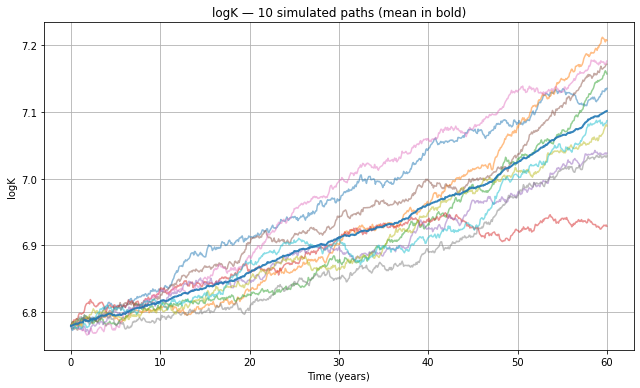

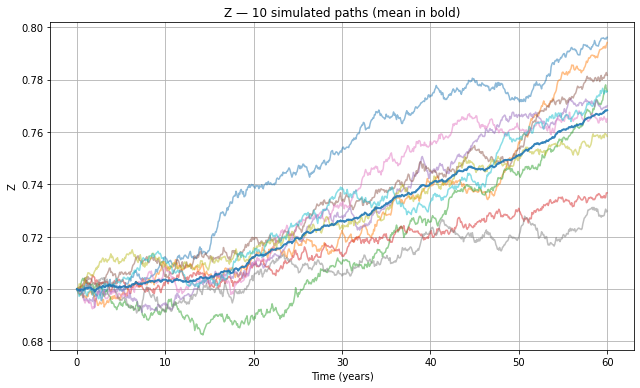

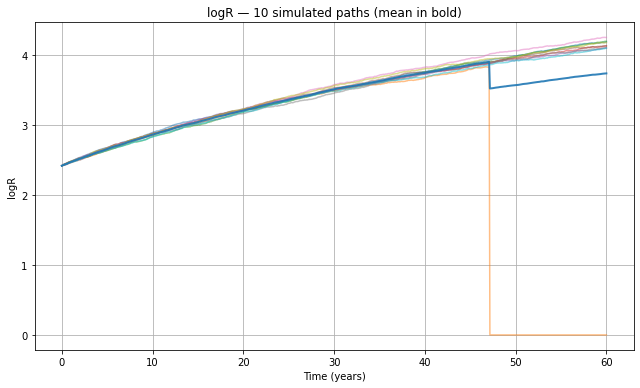

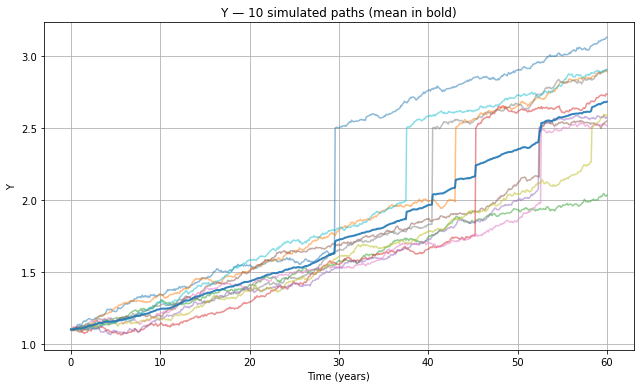

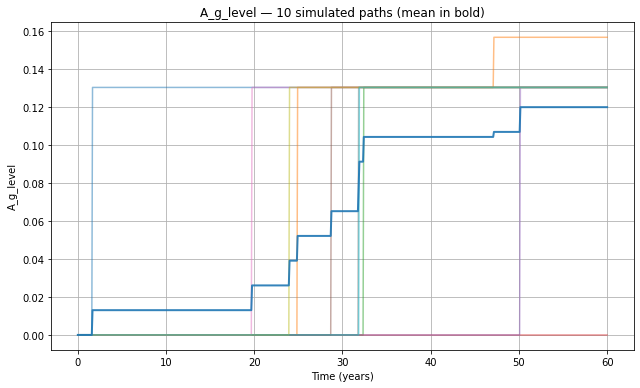

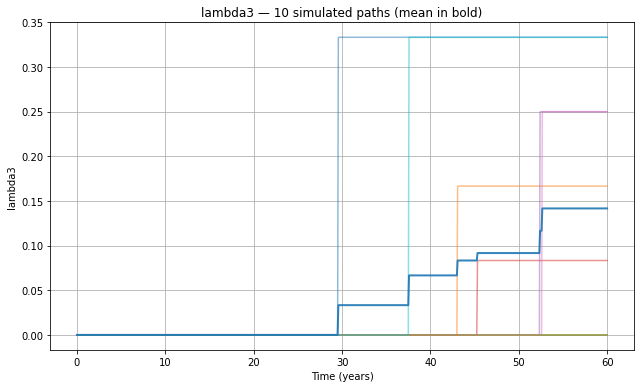

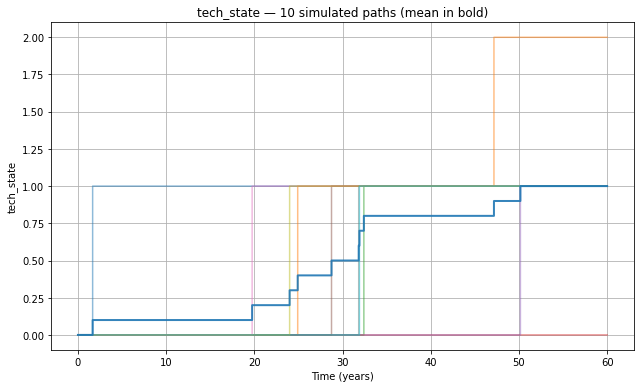

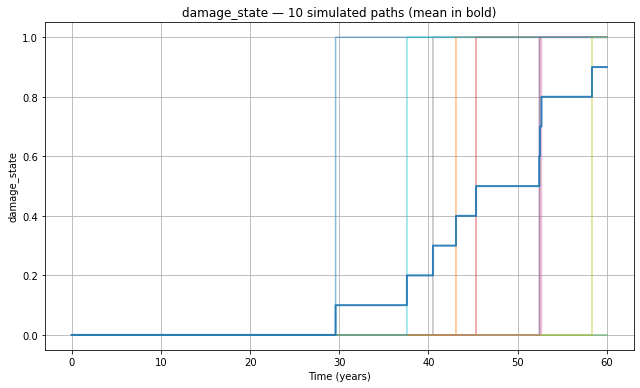

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Assumes these exist: logK_array, Z_array, logR_array, Y_array, A_array, λ3_array (or lambda3_array), T_array, D_array

arrays = {
    "logK": logK_array,
    "Z": Z_array,
    "logR": logR_array,
    "Y": Y_array,
    "A_g_level": A_array,
    "lambda3": λ3_array if 'λ3_array' in globals() else lambda3_array,
    "tech_state": T_array,
    "damage_state": D_array,
}

# Time axis in years (arrays have shape: n_paths x (T+1))
T_total = next(arr.shape[1] - 1 for arr in arrays.values() if arr is not None)
t_years = np.arange(T_total + 1) / 12.0

out_dir = "./sim_plots"
os.makedirs(out_dir, exist_ok=True)

def plot_paths(varname, arr, discrete=False):
    if arr is None:
        return
    n_paths = arr.shape[0]
    plt.figure(figsize=(9, 5.5))
    if discrete:
        for i in range(n_paths):
            plt.plot(t_years, arr[i, :], drawstyle="steps-post", alpha=0.5)
        mean_path = arr.mean(axis=0)
        plt.plot(t_years, mean_path, drawstyle="steps-post", linewidth=2.0, alpha=0.9)
    else:
        for i in range(n_paths):
            plt.plot(t_years, arr[i, :], alpha=0.5)
        mean_path = arr.mean(axis=0)
        plt.plot(t_years, mean_path, linewidth=2.0, alpha=0.9)

    plt.xlabel("Time (years)")
    plt.ylabel(varname)
    plt.title(f"{varname} — {n_paths} simulated paths (mean in bold)")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{varname}_paths.png"), dpi=150)
    plt.show()

# Continuous variables
plot_paths("logK", arrays["logK"])
plot_paths("Z", arrays["Z"])
plot_paths("logR", arrays["logR"])
plot_paths("Y", arrays["Y"])
plot_paths("A_g_level", arrays["A_g_level"])
plot_paths("lambda3", arrays["lambda3"])

# Discrete regime variables (plotted as steps)
plot_paths("tech_state", arrays["tech_state"], discrete=True)
plot_paths("damage_state", arrays["damage_state"], discrete=True)
